## Path and parameters configuration

In [ ]:
#%pip install -r requirements.txt

In [ ]:
# Installing ffmpeg-python package in Anaconda prompt for video processing
#pip install static-ffmpeg

In [ ]:
import shutil
import os

# Test system visibility for execution tools
print(f"⚙️ FFmpeg Executable Found?: {shutil.which('ffmpeg') is not None}")
print(f"🔍 FFprobe Executable Found?: {shutil.which('ffprobe') is not None}")

# Find the absolute path to the active ffmpeg executable
bin_dir = os.path.dirname(shutil.which('ffmpeg'))
print("\n--- ffmpeg Executable Directory---")
print(bin_dir)

print("\n--- Current Active Environment Variables ---")
print(os.environ["PATH"].split(os.path.pathsep)[-3:-2]) # Prints the latest added paths

⚙️ FFmpeg Executable Found?: True
🔍 FFprobe Executable Found?: True

--- ffmpeg Executable Directory---
D:\Others\Anaconda\envs\Affective-Computing-2026\Lib\site-packages\static_ffmpeg\bin\win32

--- Current Active Environment Variables ---
['D:\\Others\\Anaconda\\envs\\Affective-Computing-2026\\Lib\\site-packages\\static_ffmpeg\\bin\\win32']


In [15]:
%pip list

Package                Version
---------------------- ------------
annotated-doc          0.0.5
annotated-types        0.8.0
anyio                  4.15.1
audioread              3.1.0
backcall               0.2.0
backports.tarfile      1.2.0
captum                 0.9.0
certifi                2026.7.22
cffi                   2.1.1
charset-normalizer     3.5.1
click                  8.5.0
colorama               0.4.6
comm                   0.2.3
contourpy              1.3.1
cycler                 0.12.1
debugpy                1.8.21
decorator              5.1.1
dlib                   19.22.99
docutils               0.23
exceptiongroup         1.3.1
facenet-pytorch        2.6.0
ffmpeg-python          0.2.0
filelock               4.0.7
fonttools              4.63.0
fsspec                 2026.9.0
future                 1.0.0
h11                    0.16.0
hf-xet                 1.6.0
httpcore               1.0.9
httpx                  0.28.1
huggingface_hub        1.33.0
id                

In [ ]:
import os, config

os.environ["HF_TOKEN"] = config.HF_TOKEN

In [17]:
from pathlib import Path

DATA_DIR = Path("D:/University-Masters/Semester_3/P1_Affective_Computing/Lab/Project/MELD/Dataset/MELD.Raw")  # folder that directly contains the csvs / *_splits folders

SPLITS = {
    "train": {
        "csv": DATA_DIR / "train_sent_emo.csv",
        "video_dir": DATA_DIR / "train_splits",
    },
    "dev": {
        "csv": DATA_DIR / "dev_sent_emo.csv",
        "video_dir": DATA_DIR / "dev_splits",
    },
    "test": {
        "csv": DATA_DIR / "test_sent_emo.csv",
        "video_dir": DATA_DIR / "test_splits",
    },
}

In [18]:
FEATURE_CACHE_DIR = Path("D:/University-Masters/Semester_3/P1_Affective_Computing/Lab/Project/MELD/Project_Files/feature_cache")  # where cached per-utterance .pt files go
FAILURE_LOG_DIR = Path("D:/University-Masters/Semester_3/P1_Affective_Computing/Lab/Project/MELD/Project_Files/logs")  # where failure logs go

In [19]:
# MELD's 7-class emotion label set, in the order used by the original paper's
# one-hot encoding (kept for consistency if you ever compare against their weights).
EMOTION_LABELS = ["neutral", "surprise", "fear", "sadness", "joy", "disgust", "anger"]
EMOTION2IDX = {label: i for i, label in enumerate(EMOTION_LABELS)}

SENTIMENT_LABELS = ["neutral", "positive", "negative"]
SENTIMENT2IDX = {label: i for i, label in enumerate(SENTIMENT_LABELS)}

In [20]:
# Pretrained checkpoints (all pulled automatically from the Hugging Face Hub
# the first time you run extract_features.py; cached locally after that).
TEXT_MODEL_NAME = "roberta-base"
AUDIO_MODEL_NAME = "facebook/wav2vec2-base"  # self-supervised base model (no ASR head)
VISUAL_MODEL_NAME = "trpakov/vit-face-expression"  # ViT fine-tuned on FER2013

In [21]:
AUDIO_SAMPLE_RATE = 16000
NUM_VISUAL_FRAMES = 5  # frames sampled per clip, evenly spaced

# Embedding dimensionalities produced by the above checkpoints (used by
# downstream model code; you shouldn't need to change these unless you swap
# in different checkpoints).
TEXT_EMBED_DIM = 768
AUDIO_EMBED_DIM = 768
VISUAL_EMBED_DIM = 768

In [22]:
def video_path_for(split: str, dialogue_id: int, utterance_id: int) -> Path:
    """MELD's raw clips are named dia{D}_utt{U}.mp4."""
    video_dir = SPLITS[split]["video_dir"]
    return Path(video_dir) / f"dia{dialogue_id}_utt{utterance_id}.mp4"


def cache_path_for(split: str, dialogue_id: int, utterance_id: int) -> Path:
    return Path(FEATURE_CACHE_DIR) / split / f"dia{dialogue_id}_utt{utterance_id}.pt"

## Step 1 - Data audit

Before spending hours extracting features, we will make sure the data is actually
what we think it is: every row in the csv has a matching .mp4, the label
distribution looks like the published MELD stats, and there are no
surprises (missing files, empty transcripts, duplicate ids).

In [23]:
import argparse
from collections import Counter

import pandas as pd

In [24]:
def audit_split(split: str) -> None:
    csv_path = SPLITS[split]["csv"]
    video_dir = SPLITS[split]["video_dir"]

    print(f"\n{'=' * 60}\nSplit: {split}\n{'=' * 60}")
    print(f"csv:       {csv_path}")
    print(f"video_dir: {video_dir}")

    if not csv_path.exists():
        print(f"  !! csv not found -- check the path in MELD/Dataset/MELD.Raw")
        return
    if not video_dir.exists():
        print(f"  !! video_dir not found -- check the path in MELD/Dataset/MELD.Raw")
        return

    df = pd.read_csv(csv_path)
    print(f"rows in csv: {len(df)}")

    required_cols = {"Utterance", "Emotion", "Sentiment", "Dialogue_ID", "Utterance_ID"}
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        print(f"  !! csv is missing expected columns: {missing_cols}")
        return

    # 1. Check every row has a matching mp4 on disk.
    missing_videos = []
    for _, row in df.iterrows():
        vid = video_dir / f"dia{row['Dialogue_ID']}_utt{row['Utterance_ID']}.mp4"
        if not vid.exists():
            missing_videos.append(vid.name)

    if missing_videos:
        print(f"  !! {len(missing_videos)} / {len(df)} rows have NO matching .mp4")
        print(f"     first few missing: {missing_videos[:5]}")
    else:
        print(f"  OK: all {len(df)} rows have a matching .mp4")

    # 2. Check for empty / suspicious transcripts.
    empty_text = df["Utterance"].isna().sum() + (df["Utterance"].str.strip() == "").sum()
    if empty_text:
        print(f"  !! {empty_text} rows have an empty transcript")

    # 3. Label distribution (compare this against the published MELD table --
    #    train should be dominated by 'neutral', with 'disgust'/'fear' rare).
    print("\nEmotion distribution:")
    for label, count in Counter(df["Emotion"]).most_common():
        print(f"  {label:10s} {count:6d}  ({100 * count / len(df):.1f}%)")

    print("\nSentiment distribution:")
    for label, count in Counter(df["Sentiment"]).most_common():
        print(f"  {label:10s} {count:6d}  ({100 * count / len(df):.1f}%)")

    # 4. Utterance length in words -- useful later for picking a text max_length.
    word_counts = df["Utterance"].str.split().str.len()
    print(f"\nUtterance length (words): mean={word_counts.mean():.1f}, "
          f"max={word_counts.max()}, 95th pct={word_counts.quantile(0.95):.0f}")

    # 5. Rough size on disk of the video folder (helps calibrate how long
    #    feature extraction will take -- see extract_features.py).
    n_mp4 = len(list(video_dir.glob("*.mp4")))
    total_bytes = sum(f.stat().st_size for f in video_dir.glob("*.mp4"))
    print(f"\n{n_mp4} .mp4 files on disk, {total_bytes / 1e9:.2f} GB total")

In [25]:
parser = argparse.ArgumentParser()
parser.add_argument("--split", choices=["train", "dev", "test", "all"], default="all")
args, unknown = parser.parse_known_args()

splits = ["train", "dev", "test"] if args.split == "all" else [args.split]
for split in splits:
    audit_split(split)


Split: train
csv:       D:\University-Masters\Semester_3\P1_Affective_Computing\Lab\Project\MELD\Dataset\MELD.Raw\train_sent_emo.csv
video_dir: D:\University-Masters\Semester_3\P1_Affective_Computing\Lab\Project\MELD\Dataset\MELD.Raw\train_splits
rows in csv: 9989
  OK: all 9989 rows have a matching .mp4

Emotion distribution:
  neutral      4710  (47.2%)
  joy          1743  (17.4%)
  surprise     1205  (12.1%)
  anger        1109  (11.1%)
  sadness       683  (6.8%)
  disgust       271  (2.7%)
  fear          268  (2.7%)

Sentiment distribution:
  neutral      4710  (47.2%)
  negative     2945  (29.5%)
  positive     2334  (23.4%)

Utterance length (words): mean=8.0, max=69, 95th pct=20

9989 .mp4 files on disk, 7.88 GB total

Split: dev
csv:       D:\University-Masters\Semester_3\P1_Affective_Computing\Lab\Project\MELD\Dataset\MELD.Raw\dev_sent_emo.csv
video_dir: D:\University-Masters\Semester_3\P1_Affective_Computing\Lab\Project\MELD\Dataset\MELD.Raw\dev_splits
rows in csv: 1109
 

## Step 2 - Feature extraction

This code below does ONE pass over the raw clips, turns each one into
three small embedding vectors (text, audio, visual), and caches them to disk
as tiny .pt files. Every later step (model building, training, hyperparameter
search, interpretability) then reads from this small cache instead of ever
touching the 7 GB of video again. That's the whole trick for making a ~10k
clip dataset feel small: pay the decoding/model-inference cost exactly once.

In [26]:
import csv
import subprocess
import tempfile
from pathlib import Path

import cv2
import numpy as np
import soundfile as sf
import torch
from facenet_pytorch import MTCNN
from PIL import Image
from tqdm import tqdm
from transformers import (
    AutoImageProcessor,
    AutoModelForImageClassification,
    AutoTokenizer,
    AutoModel,
    Wav2Vec2FeatureExtractor,
    Wav2Vec2Model,
)

### Model loading (done once, not per-utterance)

In [27]:
def load_models(device: str):
    print(f"Loading models on {device} ...")

    tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_NAME)
    text_model = AutoModel.from_pretrained(TEXT_MODEL_NAME).to(device).eval()

    audio_extractor = Wav2Vec2FeatureExtractor.from_pretrained(AUDIO_MODEL_NAME)
    audio_model = Wav2Vec2Model.from_pretrained(AUDIO_MODEL_NAME).to(device).eval()

    visual_processor = AutoImageProcessor.from_pretrained(VISUAL_MODEL_NAME)
    visual_model = AutoModelForImageClassification.from_pretrained(VISUAL_MODEL_NAME).to(device).eval()

    mtcnn = MTCNN(image_size=224, margin=20, post_process=False, device=device)

    print("Models loaded.")
    return {
        "tokenizer": tokenizer,
        "text_model": text_model,
        "audio_extractor": audio_extractor,
        "audio_model": audio_model,
        "visual_processor": visual_processor,
        "visual_model": visual_model,
        "mtcnn": mtcnn,
    }

### Per-modality extraction

> Text Embeddings

In [28]:
@torch.no_grad()
def extract_text_embedding(text: str, models: dict, device: str) -> torch.Tensor:
    tokenizer, model = models["tokenizer"], models["text_model"]
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=64).to(device)
    outputs = model(**inputs)
    # masked mean-pool over tokens (more stable than just the CLS token for short utterances)
    mask = inputs["attention_mask"].unsqueeze(-1)
    summed = (outputs.last_hidden_state * mask).sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1)
    return (summed / counts).squeeze(0).cpu()


def _extract_audio_wav(video_path: Path, tmp_wav_path: str) -> bool:
    """Extract mono 16kHz audio from an mp4 using ffmpeg. Returns True on success."""
    cmd = [
        "ffmpeg", "-y", "-loglevel", "error",
        "-i", str(video_path),
        "-ac", "1", "-ar", str(AUDIO_SAMPLE_RATE),
        tmp_wav_path,
    ]
    result = subprocess.run(cmd, capture_output=True)
    return result.returncode == 0

> Audio Embeddings

In [29]:
@torch.no_grad()
def extract_audio_embedding(video_path: Path, models: dict, device: str) -> torch.Tensor:
    extractor, model = models["audio_extractor"], models["audio_model"]
    # Use a fixed filename in the local directory instead of a locked temp file
    local_temp_wav = "_temp_audio.wav"

    # Clear the file beforehand if an old process left it behind
    if os.path.exists(local_temp_wav):
        try:
            os.remove(local_temp_wav)
        except PermissionError:
            pass # If locked, ffmpeg's overwrite flag (-y) will handle it anyway

    # Extract audio into our local scratchpad file
    ok = _extract_audio_wav(video_path, local_temp_wav)
    if not ok:
        raise RuntimeError(f"ffmpeg failed to extract audio from {video_path}")
        
    # Read the data into memory
    speech, sr = sf.read(local_temp_wav)

    speech = speech.astype(np.float32)
    if speech.ndim > 1:  # just in case ffmpeg didn't fully downmix
        speech = speech.mean(axis=1)
    if len(speech) < 400:  # a few clips are near-silent / extremely short
        speech = np.pad(speech, (0, 400 - len(speech)))

    inputs = extractor(speech, sampling_rate=AUDIO_SAMPLE_RATE, return_tensors="pt").to(device)
    outputs = model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).squeeze(0).cpu()


def _sample_frames(video_path: Path, num_frames: int) -> list:
    cap = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return []
    indices = np.linspace(0, total - 1, num=min(num_frames, total), dtype=int)
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if ret:
            frames.append(Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
    cap.release()
    return frames

> Visual Embeddings

In [30]:
@torch.no_grad()
def extract_visual_embedding(video_path: Path, models: dict, device: str, num_frames: int):
    mtcnn = models["mtcnn"]
    processor, model = models["visual_processor"], models["visual_model"]

    frames = _sample_frames(video_path, num_frames)
    if not frames:
        raise RuntimeError(f"could not read any frames from {video_path}")

    face_images = []
    for frame in frames:
        face_tensor = mtcnn(frame)  # CxHxW, pixel range ~[0,255], or None if no face found
        if face_tensor is not None:
            face_np = face_tensor.permute(1, 2, 0).clamp(0, 255).byte().numpy()
            face_images.append(Image.fromarray(face_np))
        else:
            # MELD is a multi-party show; the speaker isn't always frontal/on-screen.
            # Falling back to the full frame keeps the pipeline moving instead of
            # dropping the utterance -- exactly the difficulty the original MELD
            # authors flagged for why they skipped the visual modality entirely.
            face_images.append(frame)

    inputs = processor(images=face_images, return_tensors="pt").to(device)

    # CLS-token embedding from the ViT backbone (the representation we fuse on)
    hidden = model.vit(pixel_values=inputs["pixel_values"]).last_hidden_state[:, 0, :]
    embedding = hidden.mean(dim=0).cpu()

    # also keep the model's own FER class probabilities, averaged over frames --
    # useful later for the interpretability / explanation step.
    logits = model(pixel_values=inputs["pixel_values"]).logits
    fer_probs = logits.softmax(dim=-1).mean(dim=0).cpu()

    return embedding, fer_probs

### Driver

In [31]:
from sklearn.model_selection import train_test_split

def get_subset(df, limit, seed=42):
    """Stratified subsample so even a small `limit` includes some examples of
    every emotion class, instead of just the first N rows in csv order (which,
    for MELD, means the first N *chronological* dialogues -- not a
    representative sample of the label distribution)."""
    if not limit or limit >= len(df):
        return df
    subset, _ = train_test_split(df, train_size=limit, stratify=df["Emotion"], random_state=seed)
    return subset.reset_index(drop=True)

In [32]:
def process_split(split: str, models: dict, device: str, limit: int, overwrite: bool):
    csv_path = SPLITS[split]["csv"]
    df = pd.read_csv(csv_path)
    if limit:
        #df = df.head(limit)
        df = get_subset(df, limit) # stratified sampling

    out_dir = cache_path_for(split, 0, 0).parent
    out_dir.mkdir(parents=True, exist_ok=True)
    FAILURE_LOG_DIR.mkdir(parents=True, exist_ok=True)
    failure_log = FAILURE_LOG_DIR / f"{split}_failures.csv"
    failures = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"extracting[{split}]"):
        dia_id, utt_id = int(row["Dialogue_ID"]), int(row["Utterance_ID"])
        out_path = cache_path_for(split, dia_id, utt_id)
        if out_path.exists() and not overwrite:
            continue

        video_path = video_path_for(split, dia_id, utt_id)
        if not video_path.exists():
            failures.append((dia_id, utt_id, "missing_video"))
            continue

        try:
            text_emb = extract_text_embedding(str(row["Utterance"]), models, device)
            audio_emb = extract_audio_embedding(str(video_path), models, device)
            visual_emb, fer_probs = extract_visual_embedding(
                str(video_path), models, device, NUM_VISUAL_FRAMES
            )
        except Exception as e:  # noqa: BLE001 -- one bad clip shouldn't kill a multi-hour job
            failures.append((dia_id, utt_id, str(e)[:200]))
            continue

        torch.save(
            {
                "text": text_emb,
                "audio": audio_emb,
                "visual": visual_emb,
                "visual_fer_probs": fer_probs,
                "label": EMOTION2IDX[row["Emotion"]],
                "emotion": row["Emotion"],
                "utterance": row["Utterance"],
                "speaker": row.get("Speaker", ""),
                "dialogue_id": dia_id,
                "utterance_id": utt_id,
            },
            out_path,
        )

    if failures:
        with open(failure_log, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["dialogue_id", "utterance_id", "reason"])
            writer.writerows(failures)
        print(f"[{split}] {len(failures)} clips failed -- see {failure_log}")
    print(f"[{split}] done. Cached features in {out_dir}")

In [33]:
parser = argparse.ArgumentParser()
parser.add_argument("--split", choices=["train", "dev", "test", "all"], default="all")
parser.add_argument("--limit", type=int, default=0, help="only process the first N rows (0 = all)")
parser.add_argument("--device", default="cuda" if torch.cuda.is_available() else "cpu")
parser.add_argument("--overwrite", action="store_true")
args, unknown = parser.parse_known_args()

models = load_models(args.device)
splits = ["train", "dev", "test"] if args.split == "all" else [args.split]
for split in splits:
    #process_split("train", models, args.device, 5000, args.overwrite)
    process_split(split, models, args.device, args.limit, args.overwrite) # just for testing

Loading models on cpu ...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

[train] 1 clips failed -- see D:\University-Masters\Semester_3\P1_Affective_Computing\Lab\Project\MELD\Project_Files\logs\train_failures.csv
[train] done. Cached features in D:\University-Masters\Semester_3\P1_Affective_Computing\Lab\Project\MELD\Project_Files\feature_cache\train


extracting[dev]: 100%|██████████| 1109/1109 [00:00<00:00, 2190.93it/s]


[dev] 1 clips failed -- see D:\University-Masters\Semester_3\P1_Affective_Computing\Lab\Project\MELD\Project_Files\logs\dev_failures.csv
[dev] done. Cached features in D:\University-Masters\Semester_3\P1_Affective_Computing\Lab\Project\MELD\Project_Files\feature_cache\dev


extracting[test]: 100%|██████████| 2610/2610 [00:02<00:00, 939.79it/s] 

[test] done. Cached features in D:\University-Masters\Semester_3\P1_Affective_Computing\Lab\Project\MELD\Project_Files\feature_cache\test


### Visual diagnostics

Concrete proof each modality is doing something real, using utterances
already in the cache. For one utterance: the detected face + landmarks,
the crop actually fed to the FER model, that model's own prediction, the
audio waveform, its mel-spectrogram, and a look at the text embedding.
Then, across everything cached so far, a PCA scatter per modality colored
by true emotion -- a sanity check before building the fusion model in M2.

In [34]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.decomposition import PCA
import librosa

In [220]:
def inspect_utterance(split: str, dialogue_id: int, utterance_id: int, models: dict, device: str):
    """Re-runs extraction for ONE utterance and plots every intermediate
    artifact. For spot-checking a handful of clips, not the whole dataset."""
    video_path = video_path_for(split, dialogue_id, utterance_id)
    csv_row = pd.read_csv(SPLITS[split]["csv"])
    row = csv_row[(csv_row.Dialogue_ID == dialogue_id) & (csv_row.Utterance_ID == utterance_id)].iloc[0]

    fig, ax = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f"{split} dia{dialogue_id}_utt{utterance_id} | \"{row['Utterance']}\" "
                 f"| speaker={row.get('Speaker','?')} | true emotion={row['Emotion']}")

    # --- visual: a middle frame + detected face + 5-point landmarks ---
    frames = _sample_frames(video_path, NUM_VISUAL_FRAMES)
    frame0 = frames[len(frames) // 2]
    boxes, probs, landmarks = models["mtcnn"].detect(frame0, landmarks=True)
    ax[0, 0].imshow(frame0)
    if boxes is not None:
        x1, y1, x2, y2 = boxes[0]
        ax[0, 0].add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                              linewidth=2, edgecolor="lime", facecolor="none"))
        ax[0, 0].scatter(landmarks[0][:, 0], landmarks[0][:, 1], c="red", s=25)
        ax[0, 0].set_title(f"detected face (p={probs[0]:.2f})")
    else:
        ax[0, 0].set_title("no face detected in this frame")

    # --- visual: the actual crop fed into the ViT model ---
    face_tensor = models["mtcnn"](frame0)
    if face_tensor is not None:
        face_np = face_tensor.permute(1, 2, 0).clamp(0, 255).byte().numpy()
    else:
        face_np = np.array(frame0)
    ax[0, 1].imshow(face_np)
    ax[0, 1].set_title("crop fed to the FER model")

    # --- visual: the FER model's own emotion prediction for this frame ---
    inputs = models["visual_processor"](images=Image.fromarray(face_np), return_tensors="pt").to(device)
    with torch.no_grad():
        logits = models["visual_model"](**inputs).logits.softmax(-1)[0].cpu().numpy()
    id2label = models["visual_model"].config.id2label
    labels_sorted = [id2label[i] for i in range(len(logits))]
    ax[0, 2].bar(labels_sorted, logits, color="steelblue")
    ax[0, 2].set_title("FER model's own prediction")
    ax[0, 2].tick_params(axis="x", rotation=45)

    # --- audio: waveform + mel-spectrogram ---
    tmp_wav = "_diagnostic_audio.wav"
    _extract_audio_wav(video_path, tmp_wav)
    speech, sr = sf.read(tmp_wav)
    speech = speech.astype(np.float32)
    t = np.arange(len(speech)) / sr
    ax[1, 0].plot(t, speech)
    ax[1, 0].set_title("waveform")
    ax[1, 0].set_xlabel("time (s)")

    mel = librosa.feature.melspectrogram(y=speech, sr=sr, n_mels=40)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    im = ax[1, 1].imshow(mel_db, aspect="auto", origin="lower", cmap="magma")
    ax[1, 1].set_title("mel-spectrogram (dB)")
    fig.colorbar(im, ax=ax[1, 1], fraction=0.046)

    # --- text: tokens actually produced, and the embedding itself ---
    tokens = models["tokenizer"].tokenize(str(row["Utterance"]))
    text_emb = extract_text_embedding(str(row["Utterance"]), models, device).numpy()
    ax[1, 2].imshow(text_emb.reshape(24, 32), cmap="viridis")
    ax[1, 2].set_title(f"text embedding (768-d)\ntokens: {tokens}", fontsize=8)
    ax[1, 2].set_xticks([]); ax[1, 2].set_yticks([])

    fig.tight_layout()
    plt.show()

cached train utterances: ['dia0_utt0', 'dia0_utt1', 'dia0_utt10', 'dia0_utt11', 'dia0_utt12', 'dia0_utt13', 'dia0_utt2', 'dia0_utt3', 'dia0_utt4', 'dia0_utt5', 'dia0_utt6', 'dia0_utt7', 'dia0_utt8', 'dia0_utt9', 'dia1000_utt0', 'dia1000_utt1', 'dia1000_utt2', 'dia1000_utt3', 'dia1001_utt0', 'dia1001_utt1', 'dia1001_utt10', 'dia1001_utt11', 'dia1001_utt2', 'dia1001_utt3', 'dia1001_utt4', 'dia1001_utt5', 'dia1001_utt6', 'dia1001_utt7', 'dia1001_utt8', 'dia1001_utt9', 'dia1002_utt0', 'dia1002_utt1', 'dia1002_utt2', 'dia1002_utt3', 'dia1002_utt4', 'dia1002_utt5', 'dia1003_utt0', 'dia1003_utt1', 'dia1003_utt2', 'dia1003_utt3', 'dia1003_utt4', 'dia1003_utt5', 'dia1003_utt6', 'dia1003_utt7', 'dia1004_utt0', 'dia1004_utt1', 'dia1004_utt2', 'dia1005_utt0', 'dia1005_utt1', 'dia1005_utt10', 'dia1005_utt11', 'dia1005_utt12', 'dia1005_utt13', 'dia1005_utt14', 'dia1005_utt15', 'dia1005_utt16', 'dia1005_utt17', 'dia1005_utt18', 'dia1005_utt19', 'dia1005_utt2', 'dia1005_utt20', 'dia1005_utt21', 'dia10

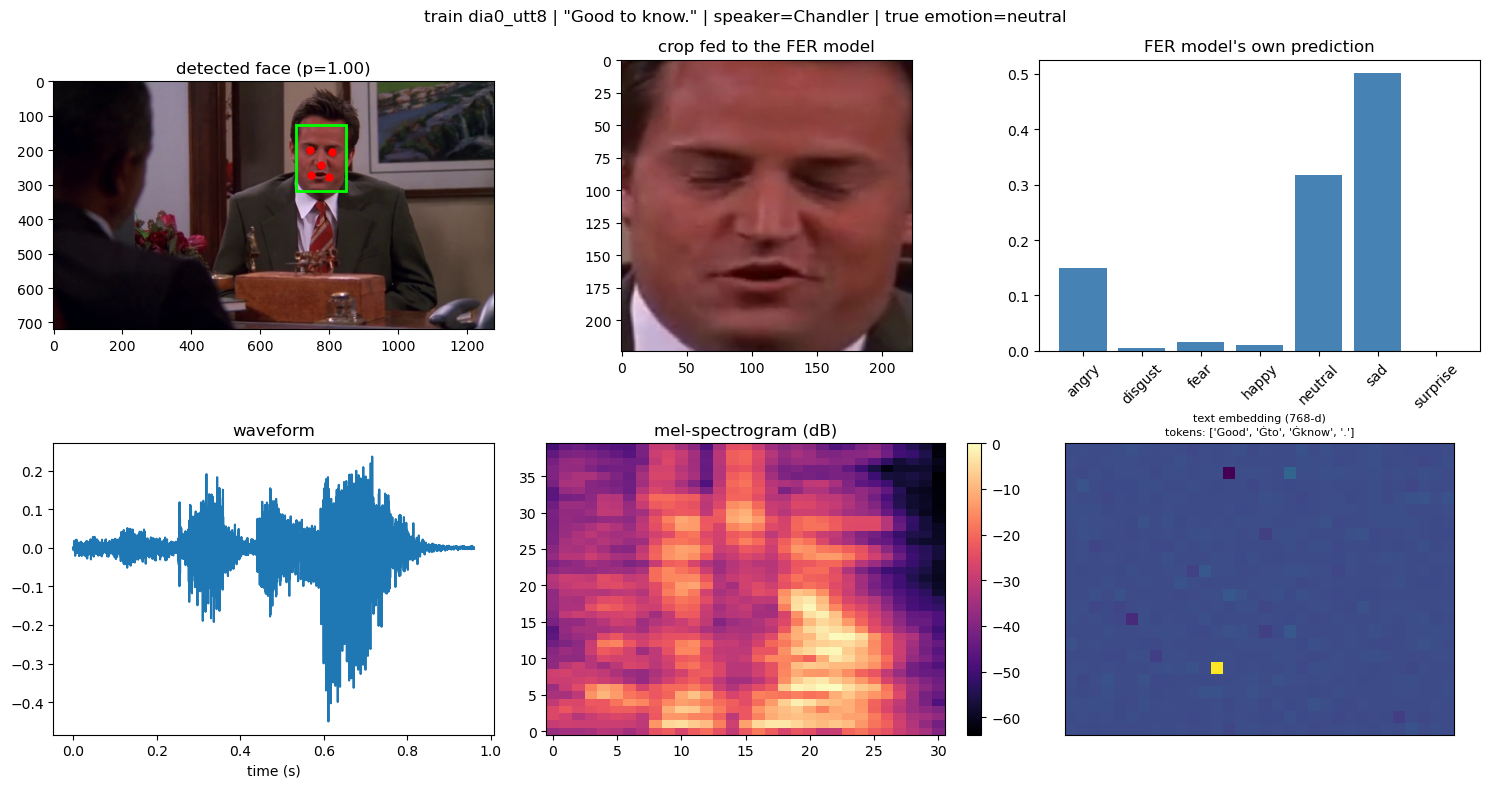

In [221]:
sample_files = sorted((FEATURE_CACHE_DIR / "train").glob("*.pt"))
print("cached train utterances:", [f.stem for f in sample_files])

dia, utt = 0, 8  # <- change to any dia{D}_utt{U} printed above
inspect_utterance("train", dia, utt, models, args.device)

Does each modality already separate emotions on its own?

With only ~10 utterances per split so far this is mostly a mechanical
check -- there aren't enough points for real clusters yet. Re-run this
after a bigger extraction (e.g. `--limit 200`) to see whether it's
actually informative before M2.

In [37]:
def plot_embedding_space(splits=("train", "dev", "test")):
    text_vecs, audio_vecs, visual_vecs, labels = [], [], [], []
    for split in splits:
        for f in (FEATURE_CACHE_DIR / split).glob("*.pt"):
            item = torch.load(f, weights_only=False)
            text_vecs.append(item["text"].numpy())
            audio_vecs.append(item["audio"].numpy())
            visual_vecs.append(item["visual"].numpy())
            labels.append(item["emotion"])

    labels = np.array(labels)
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, name, vecs in zip(axes, ["text", "audio", "visual"], [text_vecs, audio_vecs, visual_vecs]):
        coords = PCA(n_components=2).fit_transform(np.stack(vecs))
        for emo in EMOTION_LABELS:
            mask = labels == emo
            if mask.any():
                ax.scatter(coords[mask, 0], coords[mask, 1], label=emo, s=40)
        ax.set_title(f"{name} embeddings (PCA)")
    axes[-1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    fig.tight_layout()
    plt.show()
    print(f"plotted {len(labels)} utterances total")

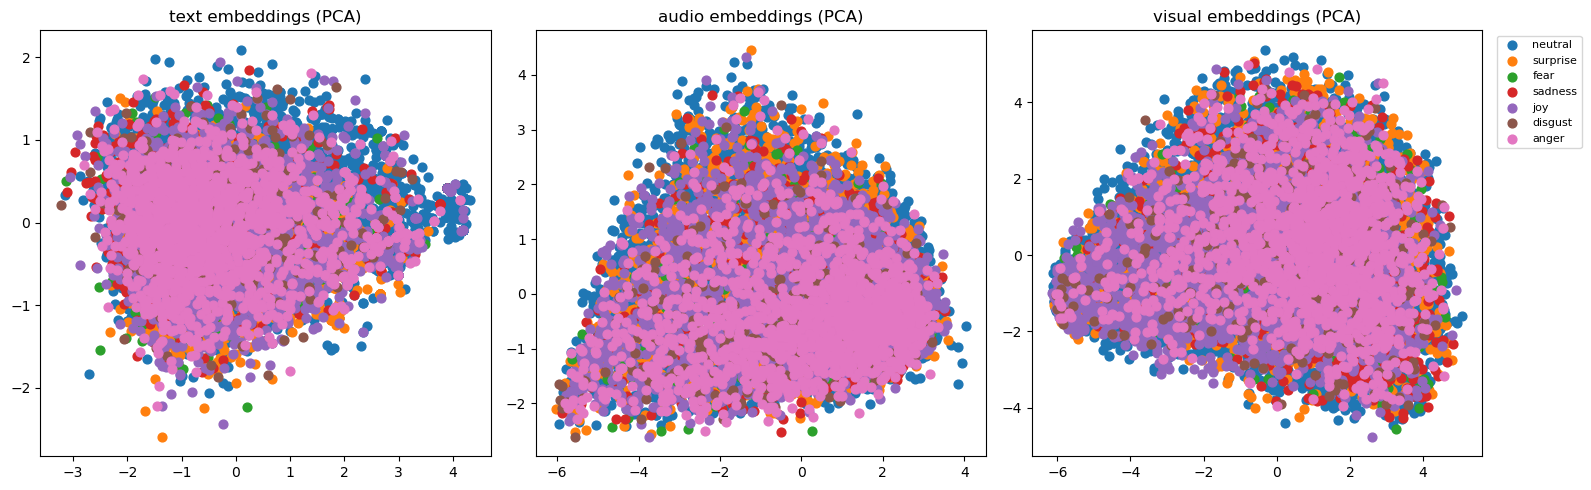

plotted 13706 utterances total


In [38]:
plot_embedding_space()

### Step 3 - PyTorch Dataset over the cached features.

Step 2 has already done all the expensive work, so loading a batch is just reading a
handful of small .pt files. No video decoding happens at training time.

In [39]:
import torch
from torch.utils.data import Dataset

> Per-sample L2 normalization

In [40]:
def normalize_modality(x, eps=1e-8):
    """L2-normalize so every modality's embedding has the same overall
    magnitude -- removes the raw-scale gap (text ~12 vs audio/visual ~5-6)
    that was inflating Integrated Gradients' attribution to text. As a side
    benefit, it also makes Shapley's zero-ablation fairer: before this,
    zeroing 'text' removed a much bigger vector than zeroing 'visual', so
    the ablations weren't even comparable in size across modalities."""
    return x / (x.norm(dim=-1, keepdim=True) + eps)

In [41]:
def load_item(path):
    """Per-sample L2-normalization: forces every modality to unit length.
    Removes ALL magnitude information -- both the across-modality scale gap
    and each utterance's own magnitude variation within a modality."""
    item = torch.load(path, weights_only=False)
    for name in ("text", "audio", "visual"):
        item[name] = normalize_modality(item[name])
    return item

> Global per-modality rescaling

In [42]:
MODALITY_SCALE = {"text": 12.04, "audio": 6.38, "visual": 5.29}  # from your earlier norm check

def rescale_modality(x, name):
    return x / MODALITY_SCALE[name]

In [43]:
def load_item_rescaled(path):
    """Global per-modality rescaling: divides by one fixed constant per
    modality (not each sample's own norm). Equalizes the three modalities'
    average scale, but preserves each utterance's own magnitude variation."""
    item = torch.load(path, weights_only=False)
    for name in ("text", "audio", "visual"):
        item[name] = rescale_modality(item[name], name)
    return item

In [44]:
class MELDFeatureDataset(Dataset):
    def __init__(self, split: str):
        self.split_dir = FEATURE_CACHE_DIR / split
        self.files = sorted(self.split_dir.glob("*.pt"))
        if not self.files:
            raise FileNotFoundError(
                f"No cached features found in {self.split_dir}. "
                f"Run the Step 2 of the notebook first."
            )

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        item = load_item(self.files[idx]) # L2-normalized embeddings
        #item = load_item_rescaled(self.files[idx]) # global per-modality rescaling
        return {
            "text": item["text"],
            "audio": item["audio"],
            "visual": item["visual"],
            "label": torch.tensor(item["label"], dtype=torch.long),
        }

In [45]:
ds = MELDFeatureDataset("train")
print(f"{args.split}: {len(ds)} cached utterances")
sample = ds[0]
for key, val in sample.items():
    print(f"  {key:8s} shape={tuple(val.shape)} dtype={val.dtype}")

from torch.utils.data import DataLoader
loader = DataLoader(ds, batch_size=8, shuffle=True)
batch = next(iter(loader))
print("\nOne batch:")
for key, val in batch.items():
    print(f"  {key:8s} shape={tuple(val.shape)}")

all: 9988 cached utterances
  text     shape=(768,) dtype=torch.float32
  audio    shape=(768,) dtype=torch.float32
  visual   shape=(768,) dtype=torch.float32
  label    shape=() dtype=torch.int64

One batch:
  text     shape=(8, 768)
  audio    shape=(8, 768)
  visual   shape=(8, 768)
  label    shape=(8,)


### Step 4 - Tri-modal fusion classifier

There are two variants of both linear and attention-based fusion model:
1. Linear Fusion (without returing static weight)
2. Linear Fusion (returing static weight)
3. Attention Fusion (Soft floor)
4. Attention Fusion (Hard floor + gate entropy penalty)

Current selection is `Linear Fusion (without returing static weight)`, if you want to select options 2 to 4 then you must require your fusion model to return weights. In that case, comment in/out the relevant classifier classes in `train_fusion_model()` and comment out `compare_attributions` and the first `modality_attribution_agreement` function and remove comments from `compare_attributions` and the second `modality_attribution_agreement` function (in Section 5).

In [46]:
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns

In [47]:
CLASS_WEIGHTS = torch.tensor([4.0, 15.0, 15.0, 3.0, 1.0, 6.0, 3.0])

> Fixed Linear Combination

Same architecture pattern as exercise 4's AVEmotionModel: frozen encoders (already baked into the cached embeddings), concatenate, train a small MLP.

* Linear Fusion not returning weights

In [49]:
class FusionClassifier(nn.Module):
    """Concatenate the three fixed embeddings, classify with a small MLP."""
    def __init__(self, text_dim=768, audio_dim=768, visual_dim=768,
                 hidden_dim=512, num_classes=7, dropout=0.3):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(text_dim + audio_dim + visual_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, text, audio, visual):
        x = torch.cat([text, audio, visual], dim=1)
        return self.classifier(x)

* Linear Fusion returning weights (static weights)

In [ ]:
# class FusionClassifier(nn.Module):
#     """Concatenate the three fixed embeddings, classify with a small MLP."""
    
#     EXPLANATION_IS_PER_EXAMPLE = False  # weights are a static property of the trained network
#     def __init__(self, text_dim=768, audio_dim=768, visual_dim=768,
#                  hidden_dim=512, num_classes=7, dropout=0.3):
#         super().__init__()
#         # Store individual dimensions to safely split weights during forward pass
#         self.text_dim = text_dim
#         self.audio_dim = audio_dim
#         self.visual_dim = visual_dim

#         self.classifier = nn.Sequential(
#             nn.Linear(text_dim + audio_dim + visual_dim, hidden_dim),
#             nn.ReLU(),
#             nn.Dropout(dropout),
#             nn.Linear(hidden_dim, num_classes),
#         )

#     def forward(self, text, audio, visual, return_weights=False):
#         x = torch.cat([text, audio, visual], dim=1)
#         logits = self.classifier(x)
        
#         if return_weights:
#             # 1. Access the first layer's weight matrix directly
#             # Shape: (hidden_dim, text_dim + audio_dim + visual_dim)
#             first_layer_weight = self.classifier[0].weight
            
#             # 2. Slice the weights corresponding to each modality
#             w_text = first_layer_weight[:, :self.text_dim]
#             w_audio = first_layer_weight[:, self.text_dim : self.text_dim + self.audio_dim]
#             w_visual = first_layer_weight[:, self.text_dim + self.audio_dim :]
            
#             # 3. Calculate actual weight magnitudes (L2 norm)
#             importance_t = torch.norm(w_text)
#             importance_a = torch.norm(w_audio)
#             importance_v = torch.norm(w_visual)
            
#             # 4. Normalize so they sum to 1.0
#             total = importance_t + importance_a + importance_v
            
#             # Create a (1, 3) tensor matching the expected batch representation
#             # and place it on the exact same device as the input features
#             weights = torch.stack([importance_t, importance_a, importance_v]) / total
#             weights = weights.unsqueeze(0)  # Shape: (1, 3)
            
#             return logits, weights
            
#         return logits

> Attention-weighted fusion

A gate network looks at all three projected modalities together and
outputs one weight per modality (summing to 1), then combines them with a
weighted sum instead of a fixed concatenation. The gate weights themselves
are a free, built-in third signal for "which modality did the model trust
here" -- alongside Shapley and Integrated Gradients.

* Attention Fusion with soft floor

In [51]:
class AttentionFusionClassifier(nn.Module):
    EXPLANATION_IS_PER_EXAMPLE = True   # gate recomputes weights from this specific input
    def __init__(self, text_dim=768, audio_dim=768, visual_dim=768,
                 proj_dim=256, hidden_dim=512, num_classes=7, dropout=0.3):
        super().__init__()
        self.text_proj = nn.Linear(text_dim, proj_dim)
        self.audio_proj = nn.Linear(audio_dim, proj_dim)
        self.visual_proj = nn.Linear(visual_dim, proj_dim)

        self.gate = nn.Sequential(
            nn.Linear(proj_dim * 3, 128),
            nn.ReLU(),
            nn.Linear(128, 3),  # one raw score per modality
        )

        self.classifier = nn.Sequential(
            nn.Linear(proj_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, text, audio, visual, return_weights=False):
        t = torch.relu(self.text_proj(text))
        a = torch.relu(self.audio_proj(audio))
        v = torch.relu(self.visual_proj(visual))

        gate_input = torch.cat([t, a, v], dim=1)
        weights = torch.softmax(self.gate(gate_input), dim=1)  # (batch, 3), sums to 1

        fused = weights[:, 0:1] * t + weights[:, 1:2] * a + weights[:, 2:3] * v
        logits = self.classifier(fused)

        if return_weights:
            return logits, weights
        return logits

* Attention Fusion with hard floor

In [52]:
class HardAttentionFusionClassifier(nn.Module):
    EXPLANATION_IS_PER_EXAMPLE = True   # gate recomputes weights from this specific input
    
    def __init__(self, text_dim=768, audio_dim=768, visual_dim=768, proj_dim=256,
                  hidden_dim=512, num_classes=7, dropout=0.3, min_weight=0.1):
        super().__init__()
        self.min_weight = min_weight
        self.text_proj = nn.Linear(text_dim, proj_dim)
        self.audio_proj = nn.Linear(audio_dim, proj_dim)
        self.visual_proj = nn.Linear(visual_dim, proj_dim)

        self.gate = nn.Sequential(
            nn.Linear(proj_dim * 3, 128),
            nn.ReLU(),
            nn.Linear(128, 3),  # one raw score per modality
        )

        self.classifier = nn.Sequential(
            nn.Linear(proj_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, text, audio, visual, return_weights=False):
        t = torch.relu(self.text_proj(text))
        a = torch.relu(self.audio_proj(audio))
        v = torch.relu(self.visual_proj(visual))

        gate_input = torch.cat([t, a, v], dim=1)
        raw_weights = torch.softmax(self.gate(gate_input), dim=1)  # (batch, 3), sums to 1

        # Hard floor: with min_weight=0.1 and 3 modalities, every weight is
        # mathematically guaranteed to land in [0.1, 0.8] -- not "discouraged
        # from going to 0", but literally incapable of it, regardless of what
        # the gate's raw logits become. No lambda to guess, no training-loop
        # change needed.
        n = raw_weights.size(1)
        weights = self.min_weight + (1 - self.min_weight * n) * raw_weights
        
        fused = weights[:, 0:1] * t + weights[:, 1:2] * a + weights[:, 2:3] * v
        logits = self.classifier(fused)

        if return_weights:
            return logits, weights
        return logits

In [53]:
@torch.no_grad()
def get_attention_weights(model, text, audio, visual, device):
    """The model's own, built-in modality-trust signal for one utterance --
    no post-hoc estimation needed, it's computed directly in the forward pass."""
    model.eval()
    _, weights = model(text.to(device), audio.to(device), visual.to(device), return_weights=True)
    weights = weights.squeeze(0).cpu().numpy()
    return {"text": float(weights[0]), "audio": float(weights[1]), "visual": float(weights[2])}

In [54]:
@torch.no_grad()
def evaluate(model, loader, device, criterion):
    model.eval()
    total, loss_sum = 0, 0.0
    all_preds, all_labels = [], []
    for batch in loader:
        text = batch["text"].to(device)
        audio = batch["audio"].to(device)
        visual = batch["visual"].to(device)
        labels = batch["label"].to(device)

        logits = model(text, audio, visual)
        loss_sum += criterion(logits, labels).item() * labels.size(0)
        all_preds.append(logits.argmax(-1).cpu())
        all_labels.append(labels.cpu())
        total += labels.size(0)

    preds = torch.cat(all_preds).numpy()
    targets = torch.cat(all_labels).numpy()
    weighted_f1 = f1_score(targets, preds, average="weighted", zero_division=0)
    return loss_sum / max(total, 1), weighted_f1, preds, targets

In [55]:
# focal loss beside plain weighted cross-entropy

class FocalLoss(nn.Module):
    """Focal loss (Lin et al., 2017): down-weights examples the model
    already classifies confidently and correctly, concentrating gradient on
    hard/misclassified ones -- which plain cross-entropy doesn't do, since
    every example is penalized by the same functional form regardless of
    confidence. `alpha` reuses CLASS_WEIGHTS, so this keeps the class-
    imbalance correction you already had and adds hard-example focusing
    on top of it."""
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        log_probs = torch.log_softmax(logits, dim=-1)
        probs = log_probs.exp()
        log_pt = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)

        loss = -((1 - pt) ** self.gamma) * log_pt
        if self.alpha is not None:
            loss = self.alpha.to(logits.device)[targets] * loss

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss

In [56]:
def apply_modality_dropout(text, audio, visual, p=0.15, training=True):
    """Randomly zero out each modality independently with probability p
    during training. Stops the gate from ever fully committing to one
    modality (any of them might be entirely absent on a given step), and
    makes Shapley's zero-ablation assumption actually valid, since the model
    now genuinely trains on zeroed-modality inputs rather than only seeing
    them for the first time during explanation."""
    if not training or p <= 0:
        return text, audio, visual
    batch_size = text.size(0)
    keep_text = (torch.rand(batch_size, 1, device=text.device) >= p).float()
    keep_audio = (torch.rand(batch_size, 1, device=text.device) >= p).float()
    keep_visual = (torch.rand(batch_size, 1, device=text.device) >= p).float()
    return text * keep_text, audio * keep_audio, visual * keep_visual

In [57]:
def gate_entropy_penalty(weights, eps=1e-8):
    """Entropy is highest at a uniform 1/3-1/3-1/3 split and lowest at a
    fully collapsed one-hot split -- penalizing low entropy discourages
    collapse. Add `lambda_entropy * gate_entropy_penalty(weights)` (try
    lambda_entropy ~0.01) to the main loss; needs forward(..., return_weights=True)
    during training to get `weights`."""
    entropy = -(weights * (weights + eps).log()).sum(dim=1).mean()
    return -entropy

In [ ]:
import random

def set_seed(seed=25):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [ ]:
def train_fusion_model(epochs=15, batch_size=8, lr=1e-3, hidden_dim=512, device="cpu",
                        patience=4, loss_fn="focal", gamma=2.0, alpha=CLASS_WEIGHTS):
    """loss_fn='focal' (default, recommended) or 'ce' (the old weighted
    cross-entropy) -- kept switchable so you can run both back-to-back for
    an ablation in the report if you want that comparison."""
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    set_seed(25)
    
    train_ds = MELDFeatureDataset("train")
    dev_ds = MELDFeatureDataset("dev")
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    dev_loader = DataLoader(dev_ds, batch_size=batch_size, shuffle=False)
    
    # FusionClassifier is a simple concatenation of embeddings.
    model = FusionClassifier(hidden_dim=hidden_dim, num_classes=len(EMOTION_LABELS)).to(device)
    
    # AttentionFusionClassifier uses a learned attention mechanism to weight the modalities.
    # Soft attention: the gate can assign any weight to each modality, including zero.
    #model = AttentionFusionClassifier(hidden_dim=hidden_dim, num_classes=len(EMOTION_LABELS)).to(device)
    
    # HardAttentionFusionClassifier uses a learned attention mechanism cannot assign a weight below min_weight to any modality.
    #model = HardAttentionFusionClassifier(hidden_dim=hidden_dim, num_classes=len(EMOTION_LABELS)).to(device)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    use_entropy_penalty = isinstance(model, HardAttentionFusionClassifier)

    if loss_fn == "focal":
        criterion = FocalLoss(alpha=alpha.to(device), gamma=gamma)
    else:
        criterion = nn.CrossEntropyLoss(weight=alpha.to(device) if alpha is not None else None)

    best_f1, best_state, epochs_without_improvement = 0.0, None, 0
    for epoch in range(1, epochs + 1):
        model.train()
        running, seen = 0.0, 0
        train_correct = 0
        for batch in train_loader:
            text, audio, visual = batch["text"].to(device), batch["audio"].to(device), batch["visual"].to(device)
            #text, audio, visual = apply_modality_dropout(text, audio, visual, p=0.15, training=True)
            labels = batch["label"].to(device)
            optimizer.zero_grad()

            # For option 1: weights not needed; For option 2, 3 or 4: weights needed
            needs_weights = isinstance(model, HardAttentionFusionClassifier)
            outputs, weights = model(text, audio, visual, return_weights=True) if needs_weights else (model(text, audio, visual), None)  
            
            loss = criterion(outputs, labels)
            if use_entropy_penalty:
                loss = loss + 0.01 * gate_entropy_penalty(weights)  # add the penalty term
            loss.backward()
            optimizer.step()
            running += loss.item() * labels.size(0)
            seen += labels.size(0)

            # --- POPULATING HISTORY: Compute training accuracy on the fly ---
            preds_train = outputs.argmax(dim=1)
            train_correct += (preds_train == labels).sum().item()
        

        val_loss, val_wf1, preds, targets = evaluate(model, dev_loader, device, criterion)
        val_macro_f1 = f1_score(targets, preds, average="macro", zero_division=0)
        print(f"epoch {epoch:2d} | train_loss={running/max(seen,1):.4f} | val_loss={val_loss:.4f} "
              f"| val_weighted_f1={val_wf1:.4f} | val_macro_f1={val_macro_f1:.4f}")

        # --- POPULATING HISTORY: Appending values to dictionary at the end of each epoch ---
        targets_np = np.array(targets)
        preds_np = np.array(preds)
                
        history['train_loss'].append(running / max(seen, 1))
        history['train_acc'].append(train_correct / max(seen, 1))
        history['val_loss'].append(val_loss)
        history['val_acc'].append((preds_np == targets_np).mean())
        # -------------------------------------------------------------------------------
        
        if val_wf1 > best_f1:
            best_f1, best_state, epochs_without_improvement = val_wf1, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"no improvement in {patience} epochs, stopping early")
                break

    model.load_state_dict(best_state)
    print(f"\nbest val weighted-F1: {best_f1:.4f}")
    return model, history

In [65]:
device = args.device  # reuse from Step 2
ALPHA_SQRT = CLASS_WEIGHTS.sqrt()  # [2.0, 3.87, 3.87, 1.73, 1.0, 2.45, 1.73] -- same ranking, gentler spread

> Cross Entropy Loss

In [66]:
# Isolation experiment: keep the normalized embeddings, revert ONLY the loss
# function back to the original weighted cross-entropy. 
model_ce, history_ce = train_fusion_model(epochs=20, batch_size=8, device=device,
                                     loss_fn="ce", alpha=ALPHA_SQRT)

epoch  1 | train_loss=1.3852 | val_loss=1.3250 | val_weighted_f1=0.3928 | val_macro_f1=0.2029
epoch  2 | train_loss=1.2109 | val_loss=1.2267 | val_weighted_f1=0.4878 | val_macro_f1=0.2929
epoch  3 | train_loss=1.1515 | val_loss=1.2251 | val_weighted_f1=0.4451 | val_macro_f1=0.2601
epoch  4 | train_loss=1.1050 | val_loss=1.1712 | val_weighted_f1=0.5284 | val_macro_f1=0.3331
epoch  5 | train_loss=1.0709 | val_loss=1.1976 | val_weighted_f1=0.5033 | val_macro_f1=0.3295
epoch  6 | train_loss=1.0345 | val_loss=1.1611 | val_weighted_f1=0.5423 | val_macro_f1=0.3595
epoch  7 | train_loss=0.9995 | val_loss=1.1584 | val_weighted_f1=0.5485 | val_macro_f1=0.3591
epoch  8 | train_loss=0.9770 | val_loss=1.1737 | val_weighted_f1=0.5518 | val_macro_f1=0.3712
epoch  9 | train_loss=0.9353 | val_loss=1.1554 | val_weighted_f1=0.5447 | val_macro_f1=0.3655
epoch 10 | train_loss=0.9125 | val_loss=1.2184 | val_weighted_f1=0.5269 | val_macro_f1=0.3500
epoch 11 | train_loss=0.8784 | val_loss=1.2135 | val_weighte

> Focal Loss

In [67]:
model_focal, history_focal = train_fusion_model(epochs=20, batch_size=8, lr=1e-3, device=device, 
                                            loss_fn="focal", alpha=ALPHA_SQRT, gamma=1.0)

epoch  1 | train_loss=2.2699 | val_loss=2.2496 | val_weighted_f1=0.4084 | val_macro_f1=0.2192
epoch  2 | train_loss=1.9572 | val_loss=2.0300 | val_weighted_f1=0.4813 | val_macro_f1=0.2882
epoch  3 | train_loss=1.8428 | val_loss=2.0390 | val_weighted_f1=0.4380 | val_macro_f1=0.2575
epoch  4 | train_loss=1.7505 | val_loss=1.9570 | val_weighted_f1=0.5283 | val_macro_f1=0.3339
epoch  5 | train_loss=1.6818 | val_loss=2.0126 | val_weighted_f1=0.4839 | val_macro_f1=0.3079
epoch  6 | train_loss=1.6091 | val_loss=1.9151 | val_weighted_f1=0.5401 | val_macro_f1=0.3740
epoch  7 | train_loss=1.5464 | val_loss=1.9248 | val_weighted_f1=0.5544 | val_macro_f1=0.3671
epoch  8 | train_loss=1.4964 | val_loss=1.9780 | val_weighted_f1=0.5423 | val_macro_f1=0.3762
epoch  9 | train_loss=1.4311 | val_loss=1.9264 | val_weighted_f1=0.5488 | val_macro_f1=0.3762
epoch 10 | train_loss=1.3658 | val_loss=2.0462 | val_weighted_f1=0.5244 | val_macro_f1=0.3472
epoch 11 | train_loss=1.3130 | val_loss=2.0718 | val_weighte

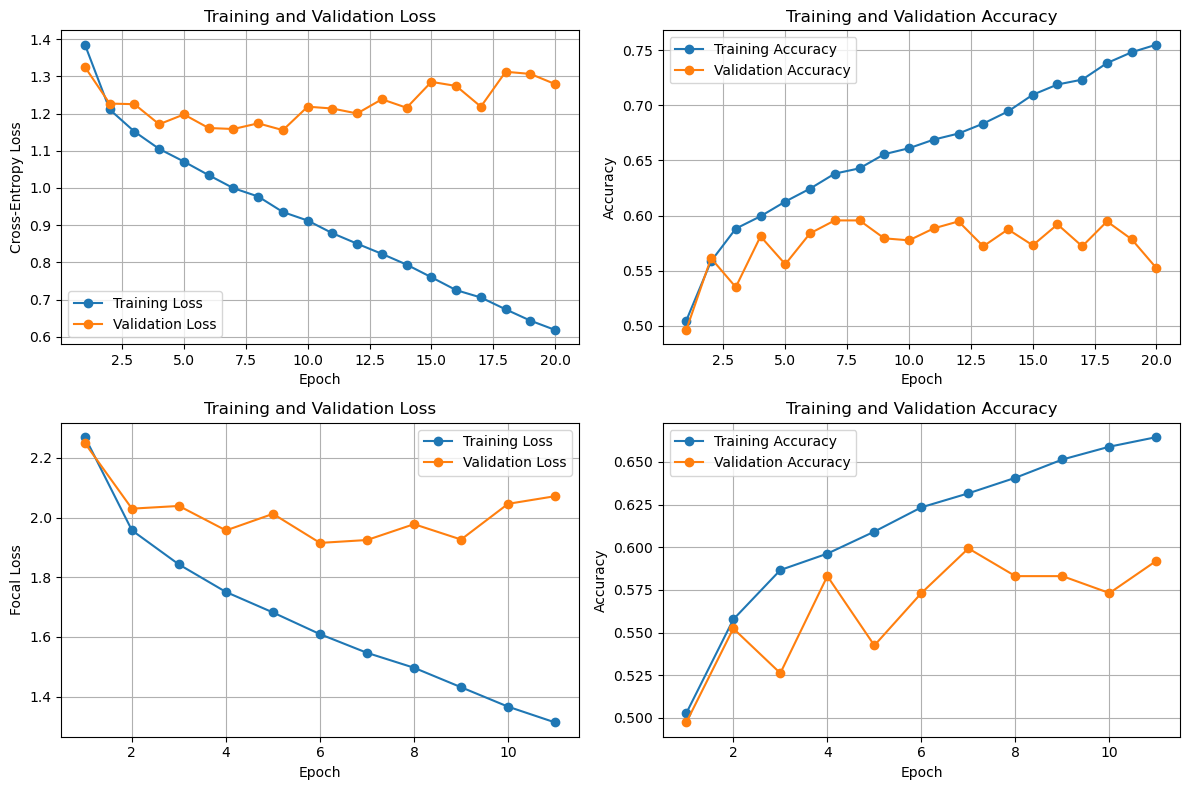

In [68]:
# --- Plotting Section ---
epochs_range_ce = range(1, len(history_ce['train_loss']) + 1)
epochs_range_focal = range(1, len(history_focal['train_loss']) + 1)

plt.figure(figsize=(12, 8))

# Plot 1: Loss curves (cross-entropy loss)
plt.subplot(2, 2, 1)
plt.plot(epochs_range_ce, history_ce['train_loss'], label='Training Loss', marker='o')
plt.plot(epochs_range_ce, history_ce['val_loss'], label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True)

# Plot 2: Accuracy curves (cross-entropy loss)
plt.subplot(2, 2, 2)
plt.plot(epochs_range_ce, history_ce['train_acc'], label='Training Accuracy', marker='o')
plt.plot(epochs_range_ce, history_ce['val_acc'], label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot 3: Loss curves (focal loss)
plt.subplot(2, 2, 3)
plt.plot(epochs_range_focal, history_focal['train_loss'], label='Training Loss', marker='o')
plt.plot(epochs_range_focal, history_focal['val_loss'], label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Focal Loss')
plt.legend()
plt.grid(True)

# Plot 4: Accuracy curves (focal loss)
plt.subplot(2, 2, 4)
plt.plot(epochs_range_focal, history_focal['train_acc'], label='Training Accuracy', marker='o')
plt.plot(epochs_range_focal, history_focal['val_acc'], label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Dev classification_report with Cross-Entropy Loss: 0.5656
              precision    recall  f1-score   support

     neutral     0.6528    0.8380    0.7339       469
    surprise     0.5590    0.6000    0.5788       150
        fear     0.1304    0.0750    0.0952        40
     sadness     0.6786    0.1712    0.2734       111
         joy     0.6142    0.4785    0.5379       163
     disgust     0.0000    0.0000    0.0000        22
       anger     0.4691    0.4967    0.4825       153

    accuracy                         0.5948      1108
   macro avg     0.4434    0.3799    0.3860      1108
weighted avg     0.5798    0.5948    0.5656      1108



Dev classification_report with Focal Loss: 0.5544
              precision    recall  f1-score   support

     neutral     0.6265    0.8870    0.7343       469
    surprise     0.5531    0.6600    0.6018       150
        fear     0.3333    0.0250    0.0465        40
     sadness     0.5172    0.1351    0.2143       111
         joy     0.680

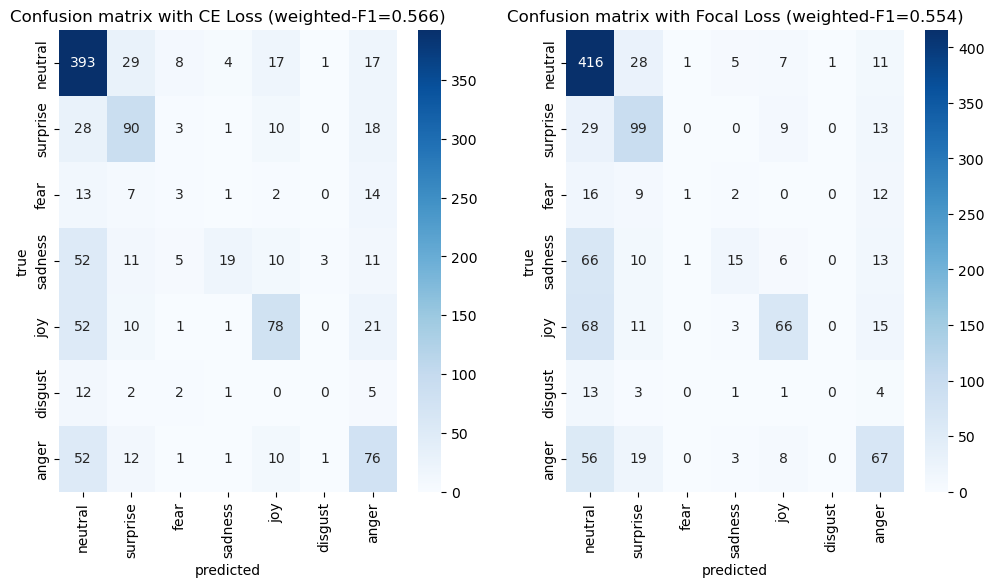

In [69]:
# -----------------------------
# Final eval + confusion matrix, same style as exercise 1/4
dev_loader = DataLoader(MELDFeatureDataset("dev"), batch_size=4, shuffle=False)
criterion_ce = nn.CrossEntropyLoss(weight=ALPHA_SQRT.to(device))
criterion_focal = FocalLoss(alpha=ALPHA_SQRT.to(device), gamma=1.0)  # Use focal loss for evaluation
_, val_f1_ce, preds_ce, targets_ce = evaluate(model_ce, dev_loader, device, criterion_ce)
_, val_f1_focal, preds_focal, targets_focal = evaluate(model_focal, dev_loader, device, criterion_focal)

print(f"Dev classification_report with Cross-Entropy Loss: {val_f1_ce:.4f}")
print(classification_report(targets_ce, preds_ce, labels=range(len(EMOTION_LABELS)), target_names=EMOTION_LABELS, digits=4, zero_division=0))
print("\n" + "="*80 + "\n")
print(f"Dev classification_report with Focal Loss: {val_f1_focal:.4f}")
print(classification_report(targets_focal, preds_focal, labels=range(len(EMOTION_LABELS)), target_names=EMOTION_LABELS, digits=4, zero_division=0))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(targets_ce, preds_ce, labels=range(len(EMOTION_LABELS))),
            annot=True, fmt="d", cmap="Blues",
            xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS)
plt.xlabel("predicted"); plt.ylabel("true")
plt.title(f"Confusion matrix with CE Loss (weighted-F1={val_f1_ce:.3f})")

plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(targets_focal, preds_focal, labels=range(len(EMOTION_LABELS))),
            annot=True, fmt="d", cmap="Blues",
            xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS)
plt.xlabel("predicted"); plt.ylabel("true")
plt.title(f"Confusion matrix with Focal Loss (weighted-F1={val_f1_focal:.3f})")

plt.show()

> Saving and Loading Model

In [165]:
TRAINED_MODELS_DIR = Path("D:/University-Masters/Semester_3/P1_Affective_Computing/Lab/Project/MELD/Project_Files/models")  # where models are saved

In [166]:
TRAINED_MODELS_DIR.mkdir(exist_ok=True)

# Save the state dictionaries
torch.save(model_ce.state_dict(), TRAINED_MODELS_DIR / "linear_fusion_cross_entropy.pt")
torch.save(model_focal.state_dict(), TRAINED_MODELS_DIR / "linear_fusion_focal_loss.pt")

print("Model weights saved successfully!")

Model weights saved successfully!


In [ ]:
'Load the classifier model you used in the previous step, and set it to evaluation mode.'
model_ce = FusionClassifier(hidden_dim=512, num_classes=len(EMOTION_LABELS))
model_focal = FusionClassifier(hidden_dim=512, num_classes=len(EMOTION_LABELS))

# model_ce = AttentionFusionClassifier(hidden_dim=512, num_classes=len(EMOTION_LABELS))
# model_focal = AttentionFusionClassifier(hidden_dim=512, num_classes=len(EMOTION_LABELS))

# model_ce = HardAttentionFusionClassifier(hidden_dim=512, num_classes=len(EMOTION_LABELS))
# model_focal = HardAttentionFusionClassifier(hidden_dim=512, num_classes=len(EMOTION_LABELS))

model_ce.load_state_dict(torch.load(TRAINED_MODELS_DIR / "linear_fusion_cross_entropy.pt", map_location=device))
model_focal.load_state_dict(torch.load(TRAINED_MODELS_DIR / "linear_fusion_focal_loss.pt", map_location=device))

model_ce = model_ce.to(device)
model_focal = model_focal.to(device)

model_ce.eval()
model_focal.eval()

print("Models successfully loaded and set to eval mode!")

Models successfully loaded and set to eval mode!


> Choose the Best Model

In [213]:
#model = model_ce
model = model_focal 

* Raw Feature Scale Analysis
    
    Geometric scale (vector magnitudes) of multimodal feature embeddings across text, audio, and visual data

In [187]:
norms = {"text": [], "audio": [], "visual": []}
for f in sorted((FEATURE_CACHE_DIR / "train").glob("*.pt"))[:30]:
    item = torch.load(f, weights_only=False)
    for name in norms:
        norms[name].append(item[name].norm().item())
for name, vals in norms.items():
    print(f"{name}: mean norm = {np.mean(vals):.2f} (+/- {np.std(vals):.2f})")

text: mean norm = 12.04 (+/- 0.52)
audio: mean norm = 6.38 (+/- 0.46)
visual: mean norm = 5.29 (+/- 0.90)


* Normalized Feature Scale Analysis

> Per-Sample L2 Normalization

1. It reads an individual sample's .pt file from disk.
2. For each modality, it calculates the specific Euclidean length `norm` of that exact utterance's vector along the last dimension.
3. It divides the vector by its own calculated length (plus a tiny eps value to safely prevent a division-by-zero error). 

Because every single vector is forced to divide by its own unique magnitude, all intensity variations are erased. Every single utterance—whether it's an aggressive scream or a quiet whisper—is stretched or shrunk until its length is exactly 1.00.


In [188]:
norms = {"text": [], "audio": [], "visual": []}
for f in sorted((FEATURE_CACHE_DIR / "train").glob("*.pt"))[:30]:
    item = load_item(f) # L2-normalized embeddings
    for name in norms:
        norms[name].append(item[name].norm().item())
for name, vals in norms.items():
    print(f"{name}: mean norm = {np.mean(vals):.2f} (+/- {np.std(vals):.2f})")

text: mean norm = 1.00 (+/- 0.00)
audio: mean norm = 1.00 (+/- 0.00)
visual: mean norm = 1.00 (+/- 0.00)


> Global Per-Modality Rescaling
1. It reads an individual sample's .pt file from disk.
2. Instead of measuring the vector's length at runtime, it checks which modality it belongs to.
3. It divides the vector by a hardcoded constant (12.04 for text, 6.38 for audio, 5.29 for visual) representing the global average length of that modality across the entire dataset. 

However, because it divides everything by a flat, unyielding constant, individual variations are perfectly preserved. An intense utterance remains a large vector, and a subtle utterance remains a small vector. 

In [189]:
norms = {"text": [], "audio": [], "visual": []}
for f in sorted((FEATURE_CACHE_DIR / "train").glob("*.pt"))[:30]:
    item = load_item_rescaled(f) # global per-modality rescaling
    for name in norms:
        norms[name].append(item[name].norm().item())
for name, vals in norms.items():
    print(f"{name}: mean norm = {np.mean(vals):.2f} (+/- {np.std(vals):.2f})")

text: mean norm = 1.00 (+/- 0.04)
audio: mean norm = 1.00 (+/- 0.07)
visual: mean norm = 1.00 (+/- 0.17)


### Section 5 - Interpretability: two independent attribution methods

> Method 1 — exact Shapley values

With only 3 "players" (modalities), the full game has just 2³=8 coalitions — cheap enough to compute the textbook Shapley value exactly rather than approximate it. We "remove" a modality by zeroing its embedding, which is the one honest caveat here: the model never saw zeroed inputs during training, so treat this as informative rather than perfectly calibrated (worth a sentence in your report's ethics discussion — explanation methods can themselves be misleading if their assumptions aren't stated).

> Method 2 — Integrated Gradients (Captum)

Aggregated from per-dimension attributions into per-modality scores, as a second, independently-derived check.

In [190]:
#%pip install captum

In [191]:
import itertools
from math import factorial
from captum.attr import IntegratedGradients

In [192]:
def shapley_modality_attribution(model, text, audio, visual, device, target_class=None):
    """Exact Shapley value of each modality's contribution to the model's
    confidence in target_class (defaults to the model's own top prediction)."""
    model.eval()
    zeros = {"text": torch.zeros_like(text), "audio": torch.zeros_like(audio), "visual": torch.zeros_like(visual)}
    full = {"text": text, "audio": audio, "visual": visual}
    modalities = ["text", "audio", "visual"]
    n = len(modalities)

    if target_class is None:
        with torch.no_grad():
            target_class = model(text.to(device), audio.to(device), visual.to(device)).argmax(-1).item()

    @torch.no_grad()
    def v(subset):
        inputs = {m: (full[m] if m in subset else zeros[m]).to(device) for m in modalities}
        return model(inputs["text"], inputs["audio"], inputs["visual"]).softmax(-1)[0, target_class].item()

    phi = {m: 0.0 for m in modalities}
    for i in modalities:
        others = [m for m in modalities if m != i]
        for r in range(len(others) + 1):
            for S in itertools.combinations(others, r):
                S = set(S)
                weight = factorial(len(S)) * factorial(n - len(S) - 1) / factorial(n)
                phi[i] += weight * (v(S | {i}) - v(S))
    return phi, target_class

In [193]:
def integrated_gradients_attribution(model, text, audio, visual, device, target_class=None):
    """Second, independent method. IG needs one differentiable input, so we
    wrap forward() to take the concatenated 2304-d vector and split it back."""
    model.eval()
    x = torch.cat([text, audio, visual], dim=1).to(device)
    baseline = torch.zeros_like(x)

    def forward_concat(x):
        t, a, v = x[:, :768], x[:, 768:1536], x[:, 1536:]
        return model(t, a, v)

    if target_class is None:
        with torch.no_grad():
            target_class = forward_concat(x).argmax(-1).item()

    ig = IntegratedGradients(forward_concat)
    attributions, _ = ig.attribute(x, baseline, target=target_class, return_convergence_delta=True)
    attributions = attributions.squeeze(0).cpu()

    phi = {
        "text": attributions[:768].abs().sum().item(),
        "audio": attributions[768:1536].abs().sum().item(),
        "visual": attributions[1536:].abs().sum().item(),
    }
    total = sum(phi.values()) or 1.0
    return {k: val / total for k, val in phi.items()}, target_class

* Comparison Table excluding Fusion Weights (linear + attention)

In [194]:
def compare_attributions(model, item, device):
    """Both methods on one utterance, side by side. Note: they're normalized
    to relative proportions purely so the bars are visually comparable --
    Shapley values are in probability units, IG attributions are gradient*input
    units, so what we're really checking is RANKING agreement, not that the
    numbers match exactly."""
    text, audio, visual = item["text"].unsqueeze(0), item["audio"].unsqueeze(0), item["visual"].unsqueeze(0)

    shap_phi, pred_class = shapley_modality_attribution(model, text, audio, visual, device)
    shap_total = sum(abs(v) for v in shap_phi.values()) or 1.0
    shap_norm = {k: v / shap_total for k, v in shap_phi.items()}
    ig_phi, _ = integrated_gradients_attribution(model, text, audio, visual, device, target_class=pred_class)

    modalities = ["text", "audio", "visual"]
    x = np.arange(len(modalities))
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(x - 0.175, [shap_norm[m] for m in modalities], 0.35, label="Shapley")
    ax.bar(x + 0.175, [ig_phi[m] for m in modalities], 0.35, label="Integrated Gradients")
    ax.set_xticks(x); ax.set_xticklabels(modalities)
    ax.set_ylabel("relative importance")
    ax.set_title(f"predicted: {EMOTION_LABELS[pred_class]} | true: {EMOTION_LABELS[item['label'].item()]}")
    ax.legend()
    plt.show()
    return shap_norm, ig_phi

#compare_attributions(model, MELDFeatureDataset("dev")[0], device)

In [195]:
def modality_attribution_agreement(model, dataset, device, n_samples=10):
    agree, total, rows = 0, 0, []
    for i in range(min(n_samples, len(dataset))):
        item = dataset[i]
        text, audio, visual = item["text"].unsqueeze(0), item["audio"].unsqueeze(0), item["visual"].unsqueeze(0)
        shap_phi, pred_class = shapley_modality_attribution(model, text, audio, visual, device)
        ig_phi, _ = integrated_gradients_attribution(model, text, audio, visual, device, target_class=pred_class)

        shap_top = max(shap_phi, key=lambda m: abs(shap_phi[m]))
        ig_top = max(ig_phi, key=lambda m: ig_phi[m])
        agree += int(shap_top == ig_top)
        total += 1
        rows.append((i, EMOTION_LABELS[pred_class], shap_top, ig_top))

    print(f"top-modality agreement: {agree}/{total} utterances ({100*agree/total:.0f}%)")
    for i, pred, s, g in rows:
        print(f"  [{'OK' if s==g else '--'}] utt {i}: predicted={pred:10s} shapley_top={s:8s} ig_top={g:8s}")

#modality_attribution_agreement(model, MELDFeatureDataset("dev"), device, n_samples=10)

* Comparison Table including Fusion Weights (linear + attention)

In [196]:
# def compare_three_models(model, item, device):
#     """Both methods on one utterance, side by side. Note: they're normalized
#     to relative proportions purely so the bars are visually comparable --
#     Shapley values are in probability units, IG attributions are gradient*input
#     units, so what we're really checking is RANKING agreement, not that the
#     numbers match exactly. The third and the latest is the model's own built-in 
#     attention weights, which are already normalized."""

#     text, audio, visual = item["text"].unsqueeze(0), item["audio"].unsqueeze(0), item["visual"].unsqueeze(0)

#     shap_phi, pred_class = shapley_modality_attribution(model, text, audio, visual, device)
#     shap_total = sum(abs(v) for v in shap_phi.values()) or 1.0
#     shap_norm = {k: v / shap_total for k, v in shap_phi.items()}
    
#     ig_phi, _ = integrated_gradients_attribution(model, text, audio, visual, device, target_class=pred_class)

#     attention_weights = get_attention_weights(model, text, audio, visual, device)

#     is_per_example = getattr(model, "EXPLANATION_IS_PER_EXAMPLE", True)
#     third_label = "Attention Weights" if is_per_example else "Static Weights (linear fusion)"

#     modalities = ["text", "audio", "visual"]
#     x = np.arange(len(modalities))
#     fig, ax = plt.subplots(figsize=(7, 4))
#     ax.bar(x - 0.25, [shap_norm[m] for m in modalities], 0.25, label="Shapley")
#     ax.bar(x, [ig_phi[m] for m in modalities], 0.25, label="Integrated Gradients")
#     ax.bar(x + 0.25, [attention_weights[m] for m in modalities], 0.25, label=third_label)
#     ax.set_xticks(x); ax.set_xticklabels(modalities)
#     ax.set_ylabel("relative importance")
#     ax.set_title(f"predicted: {EMOTION_LABELS[pred_class]} | true: {EMOTION_LABELS[item['label'].item()]}")
#     ax.legend()
#     plt.show()
#     return shap_norm, ig_phi, attention_weights

# compare_three_models(model, MELDFeatureDataset("dev")[1], device)

In [197]:
# def modality_attribution_agreement(model, dataset, device, n_samples=10):
#     agree_shap_ig, agree_shap_attn, agree_ig_attn, agree_all_three, total, rows = 0, 0, 0, 0, 0,[]
#     for i in range(min(n_samples, len(dataset))):
#         item = dataset[i]
#         text, audio, visual = item["text"].unsqueeze(0), item["audio"].unsqueeze(0), item["visual"].unsqueeze(0)
#         shap_phi, pred_class = shapley_modality_attribution(model, text, audio, visual, device)
#         ig_phi, _ = integrated_gradients_attribution(model, text, audio, visual, device, target_class=pred_class)
#         attention_weights = get_attention_weights(model, text, audio, visual, device)

#         shap_top = max(shap_phi, key=lambda m: abs(shap_phi[m]))
#         ig_top = max(ig_phi, key=lambda m: ig_phi[m])
#         attn_top = max(attention_weights, key=lambda m: attention_weights[m])

#         agree_shap_ig += int(shap_top == ig_top)
#         agree_shap_attn += int(shap_top == attn_top)
#         agree_ig_attn += int(ig_top == attn_top)
#         agree_all_three += int(shap_top == ig_top == attn_top)
#         total += 1
#         rows.append((i, EMOTION_LABELS[pred_class], shap_top, ig_top, attn_top))

#     print(f"Shapley vs IG agreement:        {agree_shap_ig}/{total} ({100*agree_shap_ig/total:.0f}%)")
#     print(f"Shapley vs Classifier agreement: {agree_shap_attn}/{total} ({100*agree_shap_attn/total:.0f}%)")
#     print(f"IG vs Classifier agreement:      {agree_ig_attn}/{total} ({100*agree_ig_attn/total:.0f}%)")
#     print(f"All three agree:                {agree_all_three}/{total} ({100*agree_all_three/total:.0f}%)")
#     for i, pred, s, g, w in rows:
#         marker = "OK" if s == g == w else "--"
#         print(f"  [{marker}] utt {i}: predicted={pred:10s} shapley_top={s:8s} ig_top={g:8s} fusion_top={w:8s}")

# modality_attribution_agreement(model, MELDFeatureDataset("dev"), device, n_samples=20)

### Selective set of modality agreement of both models

In [198]:
from torch.utils.data import Subset

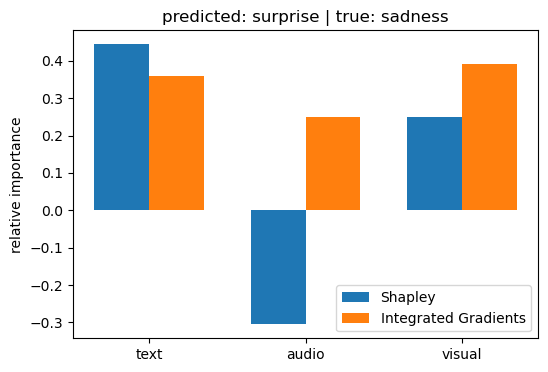

({'text': 0.4442195813021344,
  'audio': -0.3051408117951777,
  'visual': 0.2506396069026879},
 {'text': 0.35838333381025683,
  'audio': 0.2501608941829194,
  'visual': 0.3914557720068238})

In [199]:
compare_attributions(model_ce, MELDFeatureDataset("dev")[0], device)

In [200]:
dev_subset = Subset(MELDFeatureDataset("dev"), range(1, 11))
modality_attribution_agreement(model_ce, dev_subset, device, n_samples=10)

top-modality agreement: 7/10 utterances (70%)
  [--] utt 0: predicted=surprise   shapley_top=text     ig_top=visual  
  [OK] utt 1: predicted=neutral    shapley_top=visual   ig_top=visual  
  [OK] utt 2: predicted=anger      shapley_top=visual   ig_top=visual  
  [OK] utt 3: predicted=neutral    shapley_top=visual   ig_top=visual  
  [--] utt 4: predicted=surprise   shapley_top=text     ig_top=visual  
  [OK] utt 5: predicted=neutral    shapley_top=visual   ig_top=visual  
  [--] utt 6: predicted=joy        shapley_top=text     ig_top=visual  
  [OK] utt 7: predicted=neutral    shapley_top=visual   ig_top=visual  
  [OK] utt 8: predicted=neutral    shapley_top=visual   ig_top=visual  
  [OK] utt 9: predicted=neutral    shapley_top=visual   ig_top=visual  


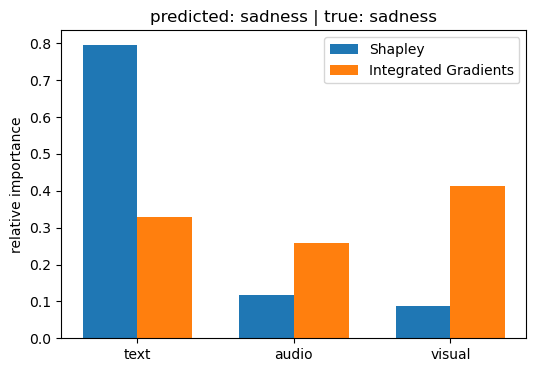

({'text': 0.7952657035919319,
  'audio': 0.11771173714840315,
  'visual': 0.08702255925966483},
 {'text': 0.3286287908383362,
  'audio': 0.25834374875594573,
  'visual': 0.4130274604057181})

In [201]:
compare_attributions(model_focal, MELDFeatureDataset("dev")[0], device)

In [202]:
dev_subset = Subset(MELDFeatureDataset("dev"), range(530, 540))
modality_attribution_agreement(model_focal, dev_subset, device, n_samples=10)

top-modality agreement: 7/10 utterances (70%)
  [OK] utt 0: predicted=neutral    shapley_top=text     ig_top=text    
  [OK] utt 1: predicted=anger      shapley_top=visual   ig_top=visual  
  [--] utt 2: predicted=neutral    shapley_top=audio    ig_top=text    
  [OK] utt 3: predicted=anger      shapley_top=visual   ig_top=visual  
  [--] utt 4: predicted=neutral    shapley_top=audio    ig_top=text    
  [OK] utt 5: predicted=joy        shapley_top=text     ig_top=text    
  [--] utt 6: predicted=neutral    shapley_top=visual   ig_top=text    
  [OK] utt 7: predicted=neutral    shapley_top=visual   ig_top=visual  
  [OK] utt 8: predicted=surprise   shapley_top=text     ig_top=text    
  [OK] utt 9: predicted=surprise   shapley_top=text     ig_top=text    


### Section 6 — LLM-generated explanations

Turns the Shapley attribution numbers into a short, natural-language
rationale. Worth running even on the current under-trained model -- if it
says a "neutral" guess was driven mostly by a modality that has no business
dominating, that's a human-readable symptom of the same overfitting problem
above, not a new one.

In [203]:
#%pip install ollama

In [209]:
import ollama

OLLAMA_MODEL = "llama3.2"

print("Downloading Llama 3.2 model files directly through the API...")
ollama.pull('llama3.2')
print("🚀 Download Complete! You are now ready to run your explain_prediction cell.")

🚀 Download Complete! You are now ready to run your explain_prediction cell.


In [210]:
def load_cached_item(split, index=0):
    files = sorted((FEATURE_CACHE_DIR / split).glob("*.pt"))
    return load_item(files[index]) # L2-normalized embeddings
    #return load_item_rescaled(files[index]) # global per-modality rescaling 

def explain_prediction(item, pred_class, shap_phi, model_name=OLLAMA_MODEL):
    shap_total = sum(abs(v) for v in shap_phi.values()) or 1.0
    shap_pct = {k: 100 * v / shap_total for k, v in shap_phi.items()}
    ranked = sorted(shap_pct.items(), key=lambda kv: -kv[1])

    prompt = f"""You are explaining an emotion-recognition model's prediction to someone with no ML background.

Utterance: "{item.get('utterance', '')}"
Speaker: {item.get('speaker', 'unknown')}
Model's predicted emotion: {EMOTION_LABELS[pred_class]}

Modality contribution to this prediction (from an exact Shapley-value analysis):
{chr(10).join(f"- {name}: {pct:.0f}%" for name, pct in ranked)}

In 2-3 plain-language sentences, explain why the model likely made this
prediction, referencing which modality (what was said, how it was said, or
facial expression) drove the decision. Do not just repeat the percentages --
weave them into a natural explanation. Do not invent details about the
utterance that weren't given to you."""

    response = ollama.chat(model=model_name, messages=[{"role": "user", "content": prompt}])
    return response["message"]["content"]

> Shapley Modality Attribution

In [214]:
item = load_cached_item("dev", 0)
text, audio, visual = item["text"].unsqueeze(0), item["audio"].unsqueeze(0), item["visual"].unsqueeze(0)
shap_phi, pred_class = shapley_modality_attribution(model, text, audio, visual, device)

print(f"predicted: {EMOTION_LABELS[pred_class]}  |  true: {item['emotion']}")
print(explain_prediction(item, pred_class, shap_phi))

predicted: sadness  |  true: sadness
Based on Phoebe's statement, the model likely made the prediction of sadness because the majority of the contribution to the decision came from the text modality, specifically the words "he's lost it" and "he's totally lost it." These phrases strongly convey a sense of disappointment, frustration, or despair, which are often associated with sadness. The model is likely inferring that Phoebe is expressing sadness because of the strong linguistic cues in her words.


In [215]:
def explanation_report(model, device, split="dev", n_samples=5):
    files = sorted((FEATURE_CACHE_DIR / split).glob("*.pt"))[:n_samples]
    for f in files:
        item = load_item(f) # L2-normalized embeddings 
        #item = load_item_rescaled(f)  # global per-modality rescaling
        
        text, audio, visual = item["text"].unsqueeze(0), item["audio"].unsqueeze(0), item["visual"].unsqueeze(0)
        shap_phi, pred_class = shapley_modality_attribution(model, text, audio, visual, device)
        print(f"--- {f.stem} ---")
        print(f"utterance: \"{item['utterance']}\"")
        print(f"predicted: {EMOTION_LABELS[pred_class]}  |  true: {item['emotion']}")
        print(explain_prediction(item, pred_class, shap_phi))
        print()

explanation_report(model, device, n_samples=5)

--- dia0_utt0 ---
utterance: "Oh my God, hes lost it. Hes totally lost it."
predicted: sadness  |  true: sadness
The model likely made this prediction because Phoebe's statement "he's lost it" is a phrase that can be interpreted as both a expression of frustration and disappointment, but also a sense of sadness. The fact that Phoebe uses the phrase in a way that suggests a strong emotional reaction, with the intensity implied by the phrase, leads the model to infer that she is primarily feeling sadness, rather than just frustration. The model is picking up on the tone and emotional intensity of Phoebe's words, which is heavily weighted towards the text modality, to make this prediction.

--- dia0_utt1 ---
utterance: "What?"
predicted: surprise  |  true: surprise
When Monica says "What?", the model likely made a surprise prediction because her tone of voice, which is conveyed through the audio modality, is quite abrupt and inquiring. This tone is more typical of surprise or questionin

> Integrated Gradient Attribution

In [216]:
item = load_cached_item("dev", 0)
text, audio, visual = item["text"].unsqueeze(0), item["audio"].unsqueeze(0), item["visual"].unsqueeze(0)
ig_phi, pred_class = integrated_gradients_attribution(model, text, audio, visual, device)

print(f"predicted: {EMOTION_LABELS[pred_class]}  |  true: {item['emotion']}")
print(explain_prediction(item, pred_class, ig_phi))

predicted: sadness  |  true: sadness
Phoebe's statement, "Oh my God, he's lost it. He's totally lost it," suggests a sense of alarm and concern for someone who has made a mistake or is in a difficult situation. The model likely made a prediction of sadness because of the text modality, specifically the words "lost it" which convey a sense of failure or despair. The way Phoebe says it, with a strong emphasis on the phrase, suggests a tone of frustration and worry, which is more closely associated with sadness.


In [217]:
def explanation_report(model, device, split="dev", n_samples=5):
    files = sorted((FEATURE_CACHE_DIR / split).glob("*.pt"))[:n_samples]
    for f in files:
        item = load_item(f) # L2-normalized embeddings 
        #item = load_item_rescaled(f)  # global per-modality rescaling
        
        text, audio, visual = item["text"].unsqueeze(0), item["audio"].unsqueeze(0), item["visual"].unsqueeze(0)
        ig_phi, pred_class = integrated_gradients_attribution(model, text, audio, visual, device)
        print(f"--- {f.stem} ---")
        print(f"utterance: \"{item['utterance']}\"")
        print(f"predicted: {EMOTION_LABELS[pred_class]}  |  true: {item['emotion']}")
        print(explain_prediction(item, pred_class, ig_phi))
        print()

explanation_report(model, device, n_samples=5)

--- dia0_utt0 ---
utterance: "Oh my God, hes lost it. Hes totally lost it."
predicted: sadness  |  true: sadness
Phoebe's strong emotional language, particularly the phrase "he's totally lost it," suggests that the model is picking up on a sense of desperation or urgency. The text modality, which includes the words she chooses, is driving the model's prediction of sadness, as it conveys a sense of distress and concern. The intensity of the language, rather than the tone or facial expression, seems to be the key factor in the model's decision.

--- dia0_utt1 ---
utterance: "What?"
predicted: surprise  |  true: surprise
When Monica said "What?", the model likely predicted surprise because the text modality, specifically the words she chose, played a significant role in this decision. The phrase "What?" is often used as an expression of surprise or inquiry, and its presence in the input likely triggered the surprise emotion. In contrast, the audio and visual modalities, although present